## Ejercicio 1: Evaluación de solicitud de crédito bancario

### Ficha PEAS

| Elemento                    | Descripción                                                                         |
|-----------------------------|-------------------------------------------------------------------------------------|
| **Percepción (S)**          | Los tres datos que llegan con cada solicitud: ingreso mensual del solicitante (en                                    soles), monto que pide prestado (en soles) y si registra o no historial moroso                                       previo.                                                                             |
| **Acciones (A)**            | Aprobar la solicitud / Aprobar con condiciones (monto menor, plazo mayor o garantía                                  adicional) / Rechazar la solicitud.                                                 |
| **Entorno (E)**             | El área de evaluación crediticia de un banco, donde llegan solicitudes con perfiles                                  económicos muy distintos y donde cada decisión implica un riesgo financiero real                                     para la entidad.                                                                    |
| **Objetivo**                | Aprobar el mayor número posible de créditos que el solicitante pueda pagar, y frenar                                 aquellos con alta probabilidad de incumplimiento.                                   |
| **Medida de desempeño (P)** | Porcentaje de créditos aprobados que terminan pagándose, monto de pérdidas por                                       morosidad, y cantidad de clientes solventes que fueron rechazados innecesariamente. |

### Justificación de las reglas

Las reglas se apoyan en la relación monto/ingreso, porque una cuota que consume una fracción
alta del sueldo mensual es la señal más directa de que el solicitante no podrá sostener el pago.
Se fija 0.30 como zona segura y 0.50 como techo de tolerancia: por debajo del primer valor la
deuda es manejable, y por encima del segundo compromete demasiado el presupuesto familiar.
El historial moroso endurece cada tramo, ya que un antecedente de incumplimiento multiplica el
riesgo aun cuando las cifras actuales parezcan razonables. La franja intermedia no se rechaza
de plano sino que se aprueba con condiciones, porque el banco pierde negocio si descarta a todo
cliente que no sea perfecto: conviene ajustarle el monto o el plazo antes que dejarlo ir.

**Reglas:**

| Condición                                        | Decisión                |
|--------------------------------------------------|-------------------------|
| Relación ≤ 0.30 y sin historial moroso           | Aprobar                 |
| Relación ≤ 0.30 con historial moroso             | Aprobar con condiciones |
| Relación entre 0.30 y 0.50, sin historial moroso | Aprobar con condiciones |
| Relación entre 0.30 y 0.50, con historial moroso | Rechazar                |
| Relación > 0.50 (con o sin historial)            | Rechazar                |

### Código

In [1]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    """
    Agente reactivo simple para evaluacion de solicitudes de credito.
    Percepcion (S): ingreso mensual, monto solicitado e historial moroso.
    Acciones (A): aprobar, aprobar con condiciones, rechazar.
    Retorna una tupla (accion, motivo).
    """
    relacion = monto_solicitado / ingreso_mensual

    if relacion > 0.50:
        return "rechazar", f"relacion monto/ingreso de {relacion:.2f} supera el limite de 0.50"

    if relacion <= 0.30:
        if tiene_historial_moroso:
            return "aprobar con condiciones", f"relacion baja ({relacion:.2f}) pero registra historial moroso"
        return "aprobar", f"relacion monto/ingreso de {relacion:.2f} dentro del rango seguro"

    # Aqui la relacion esta entre 0.30 y 0.50
    if tiene_historial_moroso:
        return "rechazar", f"relacion intermedia ({relacion:.2f}) combinada con historial moroso"
    return "aprobar con condiciones", f"relacion intermedia ({relacion:.2f}) requiere ajustar monto o plazo"

### Simulación y pruebas

In [2]:
casos = [
    (3000, 800, False),    # relacion 0.27 -> aprobar
    (3000, 800, True),     # misma relacion pero con morosidad -> aprobar con condiciones
    (2500, 1000, False),   # relacion 0.40 -> aprobar con condiciones
    (2500, 1000, True),    # relacion intermedia + morosidad -> rechazar
    (4000, 2400, False),   # relacion 0.60 -> rechazar
    (2000, 600, False),    # CASO LIMITE: relacion exactamente 0.30
    (2000, 1000, False),   # CASO LIMITE: relacion exactamente 0.50
]

for ingreso, monto, moroso in casos:
    accion, motivo = agente_credito(ingreso, monto, moroso)
    print(f"Ingreso: S/{ingreso} | Monto: S/{monto} | Moroso: {moroso}")
    print(f"   -> {accion.upper()}: {motivo}\n")

Ingreso: S/3000 | Monto: S/800 | Moroso: False
   -> APROBAR: relacion monto/ingreso de 0.27 dentro del rango seguro

Ingreso: S/3000 | Monto: S/800 | Moroso: True
   -> APROBAR CON CONDICIONES: relacion baja (0.27) pero registra historial moroso

Ingreso: S/2500 | Monto: S/1000 | Moroso: False
   -> APROBAR CON CONDICIONES: relacion intermedia (0.40) requiere ajustar monto o plazo

Ingreso: S/2500 | Monto: S/1000 | Moroso: True
   -> RECHAZAR: relacion intermedia (0.40) combinada con historial moroso

Ingreso: S/4000 | Monto: S/2400 | Moroso: False
   -> RECHAZAR: relacion monto/ingreso de 0.60 supera el limite de 0.50

Ingreso: S/2000 | Monto: S/600 | Moroso: False
   -> APROBAR: relacion monto/ingreso de 0.30 dentro del rango seguro

Ingreso: S/2000 | Monto: S/1000 | Moroso: False
   -> APROBAR CON CONDICIONES: relacion intermedia (0.50) requiere ajustar monto o plazo



### Visualización

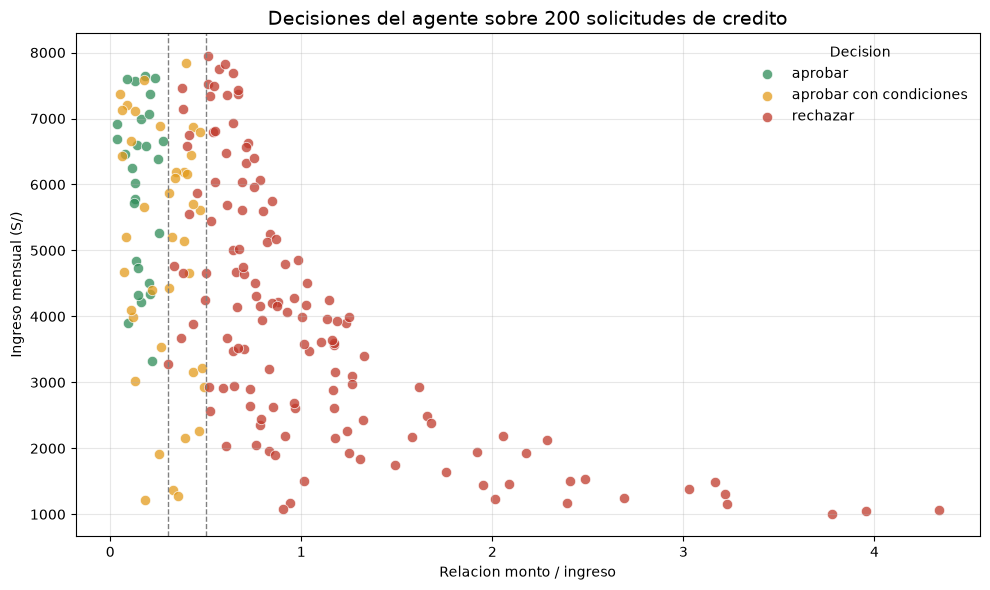

aprobar: 27 solicitudes
aprobar con condiciones: 40 solicitudes
rechazar: 133 solicitudes


In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)
n = 200

ingresos = np.random.uniform(1000, 8000, n)
montos = np.random.uniform(200, 5000, n)
morosos = np.random.rand(n) < 0.3   # aprox. 30% con historial moroso

relaciones = []
decisiones = []

for i in range(n):
    accion, _ = agente_credito(ingresos[i], montos[i], morosos[i])
    relaciones.append(montos[i] / ingresos[i])
    decisiones.append(accion)

relaciones = np.array(relaciones)
decisiones = np.array(decisiones)

colores = {
    "aprobar": "#2e8b57",
    "aprobar con condiciones": "#e39b1c",
    "rechazar": "#c0392b",
}

fig, ax = plt.subplots(figsize=(10, 6))

for accion, color in colores.items():
    mascara = decisiones == accion
    ax.scatter(
        relaciones[mascara], ingresos[mascara],
        c=color, label=accion, s=55, alpha=0.75,
        edgecolors="white", linewidths=0.6,
    )

ax.axvline(0.30, color="gray", linestyle="--", linewidth=1)
ax.axvline(0.50, color="gray", linestyle="--", linewidth=1)

ax.set_title("Decisiones del agente sobre 200 solicitudes de credito", fontsize=14)
ax.set_xlabel("Relacion monto / ingreso")
ax.set_ylabel("Ingreso mensual (S/)")
ax.legend(title="Decision", frameon=False)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for accion in colores:
    print(f"{accion}: {(decisiones == accion).sum()} solicitudes")